## Prediction of the MFM model
<b> Roberta Maria Lorenzi & Marialaura De Grazie & Ilaria Cannante</b>

contacts: robertamaria.lorenzi@unipv.it; marialaura.degrazia01@universitadipavia.it; ilaria.carannante@gmail.com


**Quick recap**
Mean Field (MF) is an approximation technique that provides a statistical summary of a spiking neural network behaviour (SNN) (Boustani and Destexhe 2009). In practice, the activity of a complex SNN (many equations!!!) is summarized through the statistical moments of membrane voltage fluctuation (average μV, the standard deviation σV and the autocorrelation time 𝜏V).

The heuristic approach used here (Zerlaut et al., 2016; 2018) relies on Transfer Function (TF) that allows to transfer microscale propeties (single neuron) into mesoscale (MF granularity).

The fundamental step to write MF equations are:

- 1) Choose a single neuron model. Here Extended Generalized LIF (E-GLIF, Geminiani et al. 2018, 2019) (see **Tutorial #1**)
- 2) Build up a spiking neural network by interconnecting neuron models (1). Here we used Brain Scaffold Builder with NEST simulator (De Schepper et al. 2022) (see **Tutorial 2**)
- 3) Fit the Transfer function on the output of the spiking neural network (2) (Zerlaut et al. 2016, 2018; Carlu et al.2020) (see **Tutorial 3**)



### 1) Single neuron model Spiking Neural Network

E-GLIF is a point neuron model derived from the leaky-integrate-and-fire model family (LIF)


### 2) Spiking Neural Network
SNN was built by interconnecting E-GLIF neurons with alpha synapses conductance and SNN activity was simulated using BSB interfaced with NEST

(Extra info: Geminiani et al.,2018 https://doi.org/10.3389/fninf.2018.00088 and Geminiani et al., 2019 https://doi.org/10.3389/fncom.2019.00035)

### 3) Transfer Funcrion Formalism (TF)

TFs are the core of this formalis, enabling us to translate single neuron properties to a mesoscale level by computing population-level conductances that in turns depend on the statistical moment of the membran potential fluctations

# Now let's make your prediction!!!
###### Once completed (1) to (3), a mean field model is ready to simulate population activity. Below some examples of cerebellar mean field model predictions

## Enjoy!

## Mean field model simulations
Second order MF for 4 cerebellar populations: GrC = Granule Cells, GoC = Golgi Cells, MLI = Molecular Layer Interneuron, PC = Purkinje Cells.

Here we tested cerebellar MF for cortical and sensory-like input:

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab: skipping Drive mount.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
day_folder = '/content/drive/MyDrive/EITN_school_2026_MFM/Day4' #UPDATE WITH YOUR PATH
os.chdir(day_folder)

In [3]:
#import the libraries
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys
sys.path.append('../')

from utils.Plotting_helper import *
from utils.TF_functions import *

In [4]:
Ngrc = 28615
Ngoc = 70
Nmossy = 2336
Nmli = 299+147
Npc = 99

In [5]:
dt = 1e-4
sim_len = 0.5

In [6]:
T = 3.5e-3
w = 0. #adaptation not included at the moment

In [7]:
params_GrC_SI = {
    'C_m': 7e-12,
    'g_L': 2.899e-10,
    'E_L': -0.062,
    'V_th': -0.041,
    'V_reset': -0.07,
    'delta_V': 0.0003,
    't_ref': 0.0015,
    'tau_m': 0.024149999999999998,
    'k_a': 2.2e-08,
    'k_2': 41.0,
    'k_1': 311.0,
    'A_2': -9.399999999999998e-13,
    'A_1': 1e-14,
    'I_e': -8.88e-13,
    'E_e': 0.0,
    'K_e': 4,
    'T_e': 0.0058,
    'Q_e': 2.3000000000000003e-10,
    'E_i': -0.08,
    'K_i': 3.6,
    'T_i': 0.01361,
    'Q_i': 2.4e-10
}

In [8]:
params_MLI_SI= {'C_m': 1.46e-11,
                'g_L': 1.6000000000000003e-09,
                'E_L': -0.068,
                'V_th': -0.053,
                'V_reset': -0.078,
                'V_spike': 0.02,
                'delta_V': 0.0035,
                'tau_V': 0.0011,
                'lambda_0': 1.8,
                't_ref': 0.00159,
                'k_a': 2.025e-06,
                'k_2': 1096.0,
                'k_1': 1887.0,
                'A_2': 5.8600000000000005e-12,
                'A_1': 5.95e-12,
                'I_e': 3.711e-12,
                'E_e': 0.0,
                'K_e': 609.9,
                'T_e': 0.00064,
                'Q_e': 1.4000000000000003e-10,
                'E_i': -0.08,
                'K_i': 14.15,
                'T_i': 0.002,
                'Q_i': 5.4945e-10}

In [9]:
params_GoC_SI={'C_m': 1.45e-10,
               'g_L': 3.2900000000000004e-09,
               'E_L': -0.062,
               'V_th': -0.055,
               'V_reset': -0.075,
               'V_spike': 0.02,
               'delta_V': 0.0004,
               'tau_V': 0.0004,
               'lambda_0': 1.0,
               't_ref': 0.002,
               'k_a': 2.17e-07,
               'k_2': 23.0,
               'k_1': 31.0,
               'A_2': 1.7801e-10,
               'A_1': 2.59988e-10,
               'I_e': 1.621e-11,
               'E_e': 0.0,
               'K_e': 0,
               'T_e': 0.0,
               'Q_e': 0.0,
               'E_i': -0.08,
               'K_i': 16.2,
               'T_i': 0.005,
               'Q_i': 1.12e-09,
               'K_e_m': 35,
               'T_e_m': 0.005,
               'Q_e_m': 2.4e-10,
               'K_e_i': 614.15,
               'T_e_i': 0.00125,
               'Q_e_i': 4.37e-10
               }

In [10]:
params_PC_SI = {
    'C_m': 3.34e-10,
    'g_L': 7.106382978723404e-09,
    'E_L': -0.059,
    'V_th': -0.043,
    'V_reset': -0.069,
    'delta_V': 0.0001,
    't_ref': 0.0005,
    'tau_m': 0.047,
    'k_a': 4.81e-07,
    'k_2': 35.0,
    'k_1': 290.0,
    'A_2': 4.96e-12,
    'A_1': 1.945e-09,
    'I_e': 1.5859e-10,
    'E_e': 0.0,
    'K_e': 1592,
    'T_e': 0.0011,
    'Q_e': 0.27e-9,
    'E_i': -0.08,
    'K_i': 8.35,
    'T_i': 0.0028,
    'Q_i': 1.22e-9
}

In [11]:
"""
params_PCZmin_SI = {
    'C_m': 3.34e-10,
    'E_L': -0.059,
    'V_th': -0.043,
    'V_reset': -0.069,
    't_ref': 0.0005,
    'tau_m': 0.047,
    'k_a': 2.0746553238369195e-07,
    'k_2': 25.023478935133806,
    'k_1': 246.2902995736806,
    'A_2': 4.612846171566953e-11,
    'A_1': 2.4340008897784705e-09,
    'I_e': 1.8539534745227857e-10,
    'E_e': 0.0,
    'K_e': 1592,
    'T_e': 0.0011,
    'Q_e': 0.27e-9,
    'E_i': -0.08,
    'K_i': 8.35,
    'T_i': 0.0028,
    'Q_i': 1.22e-9
}
"""

"\nparams_PCZmin_SI = {\n    'C_m': 3.34e-10,\n    'E_L': -0.059,\n    'V_th': -0.043,\n    'V_reset': -0.069,\n    't_ref': 0.0005,\n    'tau_m': 0.047,\n    'k_a': 2.0746553238369195e-07,\n    'k_2': 25.023478935133806,\n    'k_1': 246.2902995736806,\n    'A_2': 4.612846171566953e-11,\n    'A_1': 2.4340008897784705e-09,\n    'I_e': 1.8539534745227857e-10,\n    'E_e': 0.0,\n    'K_e': 1592,\n    'T_e': 0.0011,\n    'Q_e': 0.27e-9,\n    'E_i': -0.08,\n    'K_i': 8.35,\n    'T_i': 0.0028,\n    'Q_i': 1.22e-9\n}\n"

In [12]:
P_grc = np.load('./fitting/GrC_alpha_5_fit.npy')
P_goc = np.load('./fitting/GoC_alpha_0.56_fit.npy')
P_mli = np.load('./fitting/MLI_alpha_1.7_fit.npy')
P_pc = np.load('./fitting/PC_alpha_4.5_fit.npy')

P0_grc, P1_grc, P2_grc, P3_grc, P4_grc = P_grc[0], P_grc[1], P_grc[2], P_grc[3], P_grc[4]
P0_goc, P1_goc, P2_goc, P3_goc, P4_goc = P_goc[0], P_goc[1], P_goc[2], P_goc[3], P_goc[4]
P0_mli, P1_mli, P2_mli, P3_mli, P4_mli = P_mli[0], P_mli[1], P_mli[2], P_mli[3], P_mli[4]
P0_pc, P1_pc, P2_pc, P3_pc, P4_pc = P_pc[0], P_pc[1], P_pc[2], P_pc[3], P_pc[4]

alpha_GrC = 5
alpha_GoC = 0.56
alpha_MLI = 1.7
alpha_PC = 4.5

In [13]:
## Same funtions as Tutorial MFM we did on Thursday!

def TF_GrC(fe, fi, w):
    return TF_template_eglif(
        P0_grc, P1_grc, P2_grc, P3_grc, P4_grc,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_GrC,
        params_SI = params_GrC_SI
    )


def TF_GoC(fe_i, fe_m, fi, w):
    return TF_template_eglif_dcnp(
        P0_goc, P1_goc, P2_goc, P3_goc, P4_goc,
        fe_i = fe_i,
        fe_m = fe_m,
        fi = fi,
        adapt=0.0,
        alpha = alpha_GoC,
        params_SI = params_GoC_SI
    )

def TF_MLI(fe, fi, w):
    return TF_template_eglif(
        P0_mli, P1_mli, P2_mli, P3_mli, P4_mli,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_MLI,
        params_SI = params_MLI_SI
    )

def TF_PC(fe, fi, w):
    return TF_template_eglif(
        P0_pc, P1_pc, P2_pc, P3_pc, P4_pc,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_PC,
        params_SI = params_PC_SI
    )

In [14]:
def solve_MF_CRCTX_DCN_firstorder(TF_GrC, TF_GoC, TF_MLI, TF_PC, time, h, T,
                                   v_grc0, v_goc0, v_mli0, v_pc0,
                                   driving_input_mossy):
    #the excitation (driving input) arrives from mossy fibers - to Granule and Golgi cells

    h = time[1] - time[0]
    v_grc = np.zeros_like(time)
    v_goc = np.zeros_like(time)
    v_mli = np.zeros_like(time)
    v_pc = np.zeros_like(time)

    v_grc[0], v_goc[0], v_mli[0], v_pc[0] = v_grc0, v_goc0, v_mli0, v_pc0

    w = np.zeros(len(time)) # there is no adaptation

    for t in range(1, len(time)):
        ## MFM CRBL CTX
        TF_GrC_MF = TF_GrC(driving_input_mossy[t-1], v_goc[t-1], w[t-1])
        TF_GoC_MF  = TF_GoC(v_grc[t-1], driving_input_mossy[t-1], v_goc[t-1], w[t-1])
        TF_MLI_MF = TF_MLI(v_grc[t-1], v_mli[t-1], w[t-1])
        TF_PC_MF = TF_PC(v_grc[t-1], v_mli[t-1], w[t-1])

        v_grc[t]  = v_grc[t-1] + (h / T) * (TF_GrC_MF - v_grc[t-1])
        v_goc[t]   = v_goc[t-1]  + (h / T) * (TF_GoC_MF  - v_goc[t-1])
        v_mli[t]   = (v_mli[t-1]  + (h / T) * (TF_MLI_MF  - v_mli[t-1]))*0
        v_pc[t]   = v_pc[t-1]  + (h / T) * (TF_PC_MF  - v_pc[t-1])


    return v_grc, v_goc, v_mli, v_pc

In [15]:
def plot_my_mfm(v_pc, v_mli, v_goc, v_grc, name_sim = 'test'):

    plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 2.5
    })

    fig, axs = plt.subplots(
        5, 1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True
    )

    signals = [
        (v_pc, 'PC', 'green'),
        (v_mli, 'MLI', 'orange'),
        (v_goc, 'GoC', 'blue'),
        (v_grc, 'GrC', 'red'),
        (driving_input_mossy, 'mfs', 'black'),
        ]

    for ax, (signal, title, color) in zip(axs, signals):
        ax.plot(time, signal, color=color)
        #ax.set_ylabel('[Hz]')
        ax.set_title(title)
        ax.set_ylim([0, np.max(signal)+0.25*np.max(signal)])
        ax.grid(alpha=0.3)

    axs[-1].set_xlabel('Time [s]')
    axs[2].set_ylabel('Firing rate [Hz]')

    # Salvataggio nella working directory
    filename = os.path.join(os.getcwd(), "NET_CRCTX_DCN"+name_sim+".pdf")
    #plt.savefig(filename, dpi=300, bbox_inches='tight')

    print(f"Figure saved in:\n{filename}")

    plt.show()

In [16]:
#mean field time constant
T = 3.5e-3
#T = 1e-3

In [17]:
#initial condition


v_grc0 = 0.5
v_goc0 = 5
v_mli0 = 15
v_pc0 = 30 #zmin

In [18]:
#simulators parameters
dt = 1e-4
time = np.arange(0, 3 + dt, dt)
h = 1e-4

In [19]:
#A = 20 #centro della mia sinusoide
#freq = 5

#driving_input_mossy = A + A * np.sin(2*np.pi *freq * time)

#plt.plot(time, driving_input_mossy, 'black')

In [20]:
driving_input_mossy = np.random.rand(len(time))*1

Figure saved in:
/content/drive/MyDrive/EITN_school_2026_MFM/Day4/NET_CRCTX_DCNtest.pdf


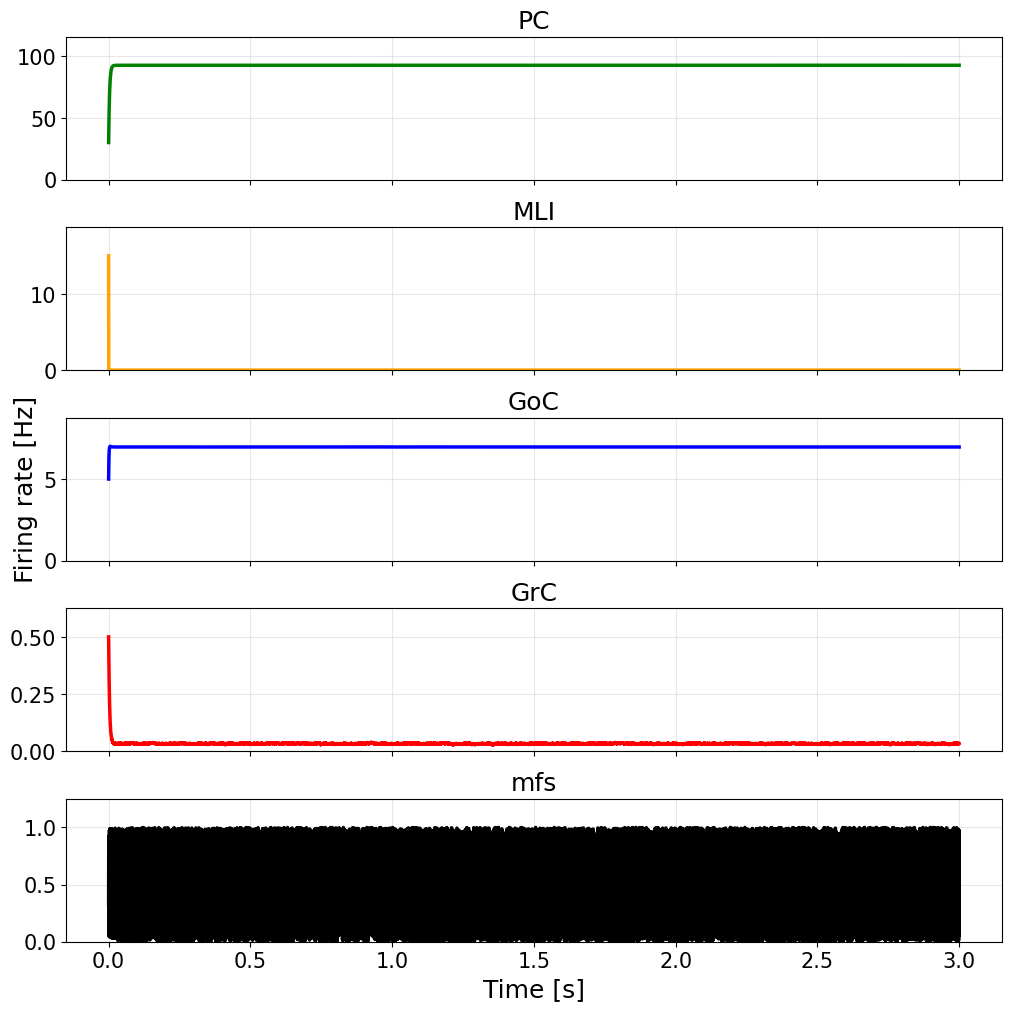

In [21]:
v_grc, v_goc, v_mli, v_pc = solve_MF_CRCTX_DCN_firstorder(TF_GrC, TF_GoC, TF_MLI, TF_PC,
                                                                          time, h, T,
                                                                          v_grc0, v_goc0, v_mli0, v_pc0,
                                                                          driving_input_mossy)

plot_my_mfm(v_pc, v_mli, v_goc, v_grc, name_sim = 'test')
